# Decoder-only Transformer: Genre-conditioned Story Generation

This notebook implements a decoder-only Transformer from scratch in PyTorch for genre-conditioned story generation. It is runnable end-to-end: data loading, tokenizer & vocabulary, model, training/validation loops, checkpointing, plotting, and sampling (temperature + top-k).

## 1. Imports & Device

In [20]:
import math
import random
from collections import Counter
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from typing import List, Tuple

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 2. Load dataset splits

In [21]:
# adjust paths if needed
train_df = pd.read_csv('../data/train.csv')
val_df = pd.read_csv('../data/val.csv')
test_df = pd.read_csv('../data/test.csv')

print('train / val / test sizes:', len(train_df), len(val_df), len(test_df))

train / val / test sizes: 699 150 151


## 3. Genre-conditioning and text preparation

In [22]:
def make_text(row):
    genre = str(row['genre']).replace(' ', '_')
    return f'<GENRE_{genre}> ' + str(row['story'])

train_texts = train_df.apply(make_text, axis=1).tolist()
val_texts = val_df.apply(make_text, axis=1).tolist()
test_texts = test_df.apply(make_text, axis=1).tolist()

# quick sanity
print('Example:', train_texts[0][:200])

Example: <GENRE_Space_Opera> In the distant reaches of the galaxy, a starship called the Starfarer was on a mission. Its crew, a diverse group of humans and aliens, had been on a quest for a mythical artifact.


## 4. Tokenizer & Vocabulary

In [23]:
# Simple whitespace tokenizer. Replace with a subword tokenizer if desired.
SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
counter = Counter()
for t in train_texts:
    counter.update(t.lower().split())

vocab = SPECIAL_TOKENS + sorted(counter.keys())
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
VOCAB_SIZE = len(vocab)

print('Vocab size:', VOCAB_SIZE)

Vocab size: 28007


In [24]:
def encode(text: str) -> List[int]:
    return [word2idx.get(w, word2idx['<UNK>']) for w in text.lower().split()]

MAX_LEN = 256

def prepare_sequence(text: str, max_len: int = MAX_LEN) -> List[int]:
    seq = [word2idx['<SOS>']]
    seq += encode(text)
    seq += [word2idx['<EOS>']]
    seq = seq[:max_len]
    seq += [word2idx['<PAD>']] * (max_len - len(seq))
    return seq

## 5. Encode datasets (to fixed-length sequences)

In [25]:
train_sequences = [prepare_sequence(t) for t in train_texts]
val_sequences = [prepare_sequence(t) for t in val_texts]
test_sequences = [prepare_sequence(t) for t in test_texts]

train_sequences = np.array(train_sequences, dtype=np.int64)
val_sequences = np.array(val_sequences, dtype=np.int64)
test_sequences = np.array(test_sequences, dtype=np.int64)

print('train shape:', train_sequences.shape)
print('val shape:', val_sequences.shape)
print('test shape:', test_sequences.shape)

train shape: (699, 256)
val shape: (150, 256)
test shape: (151, 256)


## 6. Dataset & Dataloaders

In [26]:
class StoryDataset(Dataset):
    def __init__(self, sequences: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        x = seq[:-1]  # input tokens
        y = seq[1:]   # target tokens
        return x, y

BATCH_SIZE = 32
train_loader = DataLoader(StoryDataset(train_sequences), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(StoryDataset(val_sequences), batch_size=BATCH_SIZE, shuffle=False)

print('Dataloaders ready')

Dataloaders ready


## 7. Model: positional encoding, masked self-attention, transformer blocks (decoder-only)

In [27]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)].to(x.device)
        return x

def subsequent_mask(size):
    # mask out subsequent positions (1 = allowed, 0 = masked)
    attn_shape = (1, size, size)
    subsequent = torch.triu(torch.ones(attn_shape), diagonal=1).bool()
    return ~subsequent

class MultiHeadedSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.linear_q = nn.Linear(d_model, d_model)
        self.linear_k = nn.Linear(d_model, d_model)
        self.linear_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        # x: (batch, seq_len, d_model)
        batch_size = x.size(0)
        q = self.linear_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        k = self.linear_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        v = self.linear_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        scores = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None:
            # mask shape must be (batch, 1, seq_len, seq_len) or (1, seq_len, seq_len)
            mask = mask.unsqueeze(1).to(torch.bool)
            scores = scores.masked_fill(~mask, float('-inf'))
        probs = torch.softmax(scores, dim=-1)
        probs = self.dropout(probs)
        context = torch.matmul(probs, v)
        context = context.transpose(1,2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.out(context)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadedSelfAttention(d_model, num_heads, dropout=dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout=dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        # masked self-attention
        sa = self.self_attn(x, mask=mask)
        x = x + self.dropout(sa)
        x = self.norm1(x)
        ff = self.feed_forward(x)
        x = x + self.dropout(ff)
        x = self.norm2(x)
        return x

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=8, num_layers=6, d_ff=1024, max_len=512, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout=dropout) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
    def forward(self, x, mask=None):
        # x: (batch, seq_len)
        x = self.token_emb(x) * math.sqrt(self.token_emb.embedding_dim)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask=mask)
        x = self.ln_f(x)
        return self.head(x)  # logits

In [ ]:
# instantiate model and training objects
model = DecoderOnlyTransformer(VOCAB_SIZE, d_model=256, num_heads=8, num_layers=4, d_ff=1024, max_len=512, dropout=0.1).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<PAD>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
print(model)

DecoderOnlyTransformer(
  (token_emb): Embedding(28007, 256)
  (pos_enc): PositionalEncoding()
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (self_attn): MultiHeadedSelfAttention(
        (linear_q): Linear(in_features=256, out_features=256, bias=True)
        (linear_k): Linear(in_features=256, out_features=256, bias=True)
        (linear_v): Linear(in_features=256, out_features=256, bias=True)
        (out): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (ln_f)

## 8. Training & Validation loops (track losses, save best checkpoint)

In [29]:
from tqdm.notebook import tqdm
EPOCHS = 10
best_val_loss = float('inf')
train_losses = []
val_losses = []
checkpoint_dir = Path('../checkpoints')
checkpoint_dir.mkdir(exist_ok=True, parents=True)

def make_causal_mask(batch_size, seq_len):
    mask = subsequent_mask(seq_len).to(DEVICE)
    return mask.expand(batch_size, seq_len, seq_len)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} train')
    for x, y in pbar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad()
        mask = make_causal_mask(x.size(0), x.size(1))
        logits = model(x, mask=mask)
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (pbar.n + 1)})
    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)
    # validation
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(DEVICE)
            y_val = y_val.to(DEVICE)
            mask = make_causal_mask(x_val.size(0), x_val.size(1))
            logits = model(x_val, mask=mask)
            loss = criterion(logits.view(-1, VOCAB_SIZE), y_val.view(-1))
            total_val += loss.item()
    avg_val = total_val / len(val_loader)
    val_losses.append(avg_val)
    print(f'Epoch {epoch}: train_loss={avg_train:.4f} val_loss={avg_val:.4f}')
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        ckpt_path = checkpoint_dir / 'best_story_transformer.pt'
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'val_loss': avg_val}, ckpt_path)
        print('Saved best checkpoint to', ckpt_path)

# save final checkpoint
torch.save({'epoch': EPOCHS, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'val_loss': val_losses[-1]}, checkpoint_dir / 'last_story_transformer.pt')
print('Training complete')

Epoch 1 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1: train_loss=8.8399 val_loss=7.9428
Saved best checkpoint to ../checkpoints/best_story_transformer.pt


Epoch 2 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 2: train_loss=7.4431 val_loss=7.1021
Saved best checkpoint to ../checkpoints/best_story_transformer.pt


Epoch 3 train:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 8: train_loss=5.7734 val_loss=6.0856
Saved best checkpoint to ../checkpoints/best_story_transformer.pt


Epoch 9 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 9: train_loss=5.6212 val_loss=6.0097
Saved best checkpoint to ../checkpoints/best_story_transformer.pt


Epoch 10 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 10: train_loss=5.4801 val_loss=5.9414
Saved best checkpoint to ../checkpoints/best_story_transformer.pt
Training complete


## 9. Plot training & validation loss

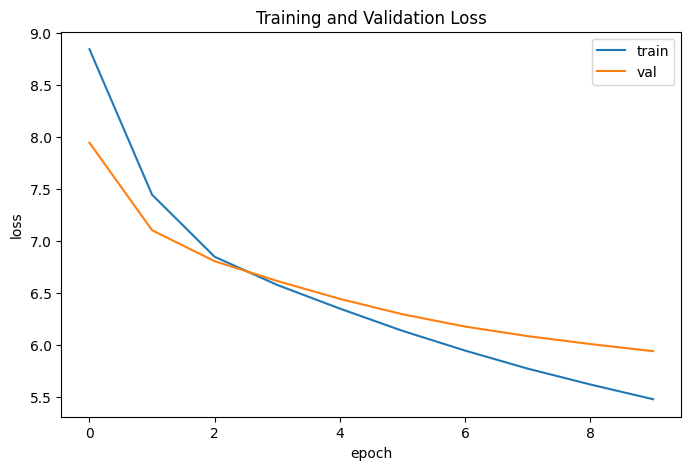

In [30]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## 10. Sampling: temperature + top-k sampling

In [33]:
def top_k_logits(logits, k):
    if k == 0:
        return logits
    v, ix = torch.topk(logits, k)
    out = logits.clone()
    out[out < v[..., -1, None]] = -float('Inf')
    return out

def sample_sequence(model, prompt: str, max_tokens=100, temperature=1.0, top_k=0):
    model.eval()
    tokens = prepare_sequence(prompt)
    tokens = tokens[:MAX_LEN]
    cur = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    generated = []
    with torch.no_grad():
        for _ in range(max_tokens):
            mask = subsequent_mask(cur.size(1)).to(DEVICE).expand(cur.size(0), -1, -1)
            logits = model(cur, mask=mask)[0, -1]  # (vocab,)
            logits = logits / max(temperature, 1e-8)
            if top_k > 0:
                logits = top_k_logits(logits, top_k)
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
            generated.append(next_id)
            if next_id == word2idx['<EOS>']:
                break
            cur = torch.cat([cur, torch.tensor([[next_id]], device=DEVICE)], dim=1)
    return ' '.join([idx2word.get(i, '<UNK>') for i in generated])

# example usage (after training) - replace prompt as desired
prompt = '<GENRE_Horror> the house was silent'
print('Sample:', sample_sequence(model, prompt, max_tokens=50, temperature=1.0, top_k=40))

RuntimeError: The size of tensor a (257) must match the size of tensor b (256) at non-singleton dimension 1

---
Notes:
- This notebook uses a simple whitespace tokenizer. For better quality, use subword tokenizers (BPE/WordPiece).
- Adjust hyperparameters (d_model, layers, lr, batch size) depending on GPU availability.
- The model and sampling are implemented to be clear and minimal; production use should add batching in sampling and improved tokenization.